##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Pose Landmarks Detection with MediaPipe Tasks

This notebook shows you how to use MediaPipe Tasks Python API to detect pose landmarks from images.

## Preparation

Let's start with installing MediaPipe.


In [1]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00


Then download an off-the-shelf model bundle. Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker#models) for more information about this model bundle.

In [2]:
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

## Visualization utilities

In [3]:
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

Now, let's download a sample video to test the function.

Finally, let's run the pose landmark detection on the downloaded video and save the output.

## Download test image

To demonstrate the Pose Landmarker API, you can download a sample image using the follow code. The image is from [Pixabay](https://pixabay.com/photos/girl-woman-fitness-beautiful-smile-4051811/).

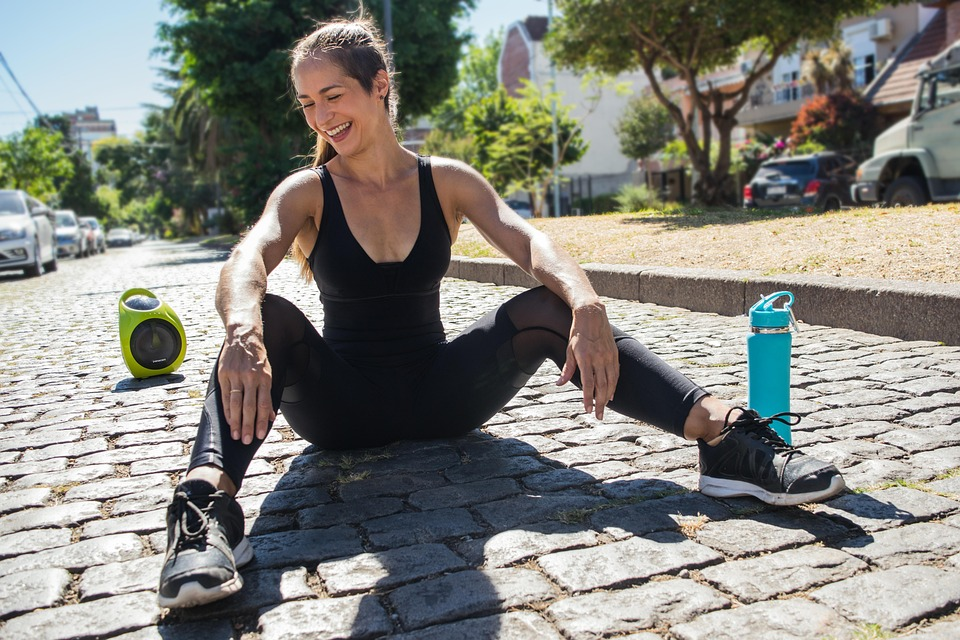

In [4]:
!wget -q -O image.jpg https://cdn.pixabay.com/photo/2019/03/12/20/39/girl-4051811_960_720.jpg

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("image.jpg")
cv2_imshow(img)

Optionally, you can upload your own image. If you want to do so, uncomment and run the cell below.

In [ ]:
# from google.colab import files
# uploaded = files.upload()

# for filename in uploaded:
#   content = uploaded[filename]
#   with open(filename, 'wb') as f:
#     f.write(content)

# if len(uploaded.keys()):
#   IMAGE_FILE = next(iter(uploaded))
#   print('Uploaded file:', IMAGE_FILE)

## Running inference and visualizing the results

The final step is to run pose landmark detection on your selected image. This involves creating your PoseLandmarker object, loading your image, running detection, and finally, the optional step of displaying the image with visualizations.

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker/python) to learn more about configuration options that this solution supports.


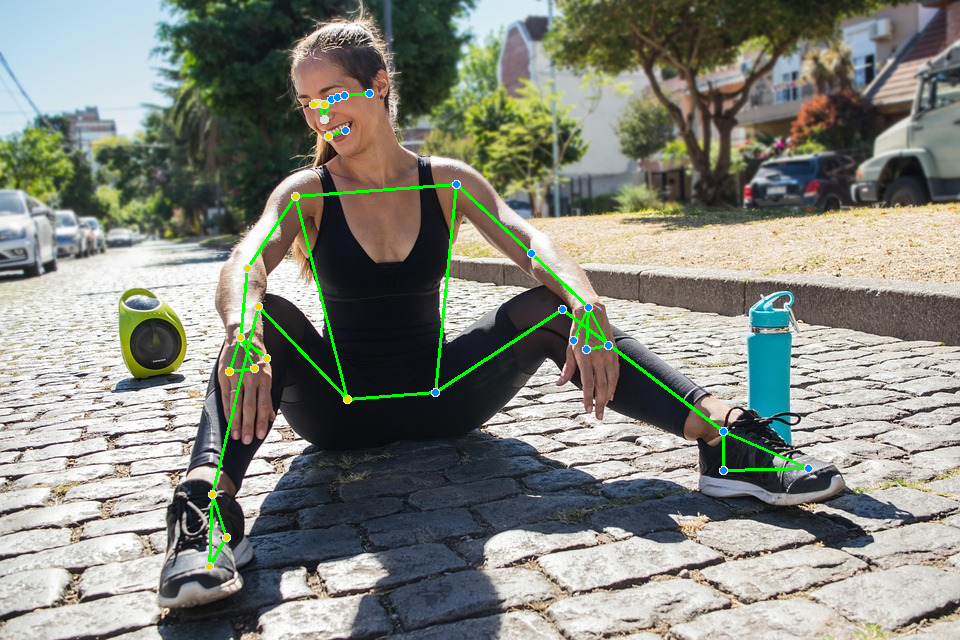

In [5]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("image.jpg")

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

Visualize the pose segmentation mask.

In [6]:
segmentation_mask = detection_result.segmentation_masks[0].numpy_view()
segmentation_mask = np.squeeze(segmentation_mask)

# Convert to 3‑channel uint8 image for visualization.
visualized_mask = (segmentation_mask * 255).astype(np.uint8)
visualized_mask = np.stack([visualized_mask]*3, axis=-1)

In [7]:
VIDEO_INPUT_PATH = '/content/-7233869658737821499_clip0002.mp4'
VIDEO_OUTPUT_PATH = 'video_with_landmarks.mp4'

print(f"Using video from: {VIDEO_INPUT_PATH}")

Using video from: /content/-7233869658737821499_clip0002.mp4


In [8]:
def process_video_with_pose_landmarks(input_video_path, output_video_path):
  # STEP 1: Create an PoseLandmarker object.
  base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
  options = vision.PoseLandmarkerOptions(
      base_options=base_options,
      output_segmentation_masks=True)
  detector = vision.PoseLandmarker.create_from_options(options)

  cap = cv2.VideoCapture(input_video_path)
  if not cap.isOpened():
      print(f"Error: Could not open video {input_video_path}")
      return None, None # Return None for results if video cannot be opened

  fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
  fps = cap.get(cv2.CAP_PROP_FPS)
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
  out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

  if not out.isOpened():
      print(f"Error: Could not create video writer for {output_video_path}")
      cap.release()
      return None, None # Return None for results if video writer cannot be created

  frame_count = 0
  detection_results_list = [] # List to store detection results per frame
  while cap.isOpened():
      ret, frame = cap.read()
      if not ret:
          break

      # Convert the BGR frame to RGB for MediaPipe
      rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

      # Create MediaPipe Image from the frame
      mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

      # Detect pose landmarks
      detection_result = detector.detect(mp_image)
      detection_results_list.append(detection_result) # Store the result

      # Draw landmarks on the RGB frame
      annotated_frame_rgb = draw_landmarks_on_image(rgb_frame, detection_result)

      # Convert the annotated RGB frame back to BGR for OpenCV writer
      annotated_frame_bgr = cv2.cvtColor(annotated_frame_rgb, cv2.COLOR_RGB2BGR)

      out.write(annotated_frame_bgr)

      frame_count += 1
      if frame_count % 100 == 0:
          print(f"Processed {frame_count} frames...")

  cap.release()
  out.release()
  print(f"Finished processing video. Output saved to {output_video_path}")
  return detection_results_list, output_video_path

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2

In [9]:
all_detection_results, output_path = process_video_with_pose_landmarks(VIDEO_INPUT_PATH, VIDEO_OUTPUT_PATH)

print(f"Total frames processed and results collected: {len(all_detection_results)}")

# Display pose landmarks for the first few frames as an example
if all_detection_results:
    print("\nPose landmarks for the first 3 frames:")
    for i, result in enumerate(all_detection_results[:3]):
        print(f"Frame {i+1}:")
        if result.pose_landmarks:
            for j, landmarks in enumerate(result.pose_landmarks):
                print(f"  Pose {j+1}: {landmarks}")
        else:
            print("  No pose landmarks detected.")

# You can then download the output video from the Colab environment
# files.download(VIDEO_OUTPUT_PATH) # Uncomment to download the processed video

Processed 100 frames...
Processed 200 frames...
Finished processing video. Output saved to video_with_landmarks.mp4
Total frames processed and results collected: 242

Pose landmarks for the first 3 frames:
Frame 1:
  Pose 1: [NormalizedLandmark(x=0.4463823437690735, y=0.4225519895553589, z=-1.027994155883789, visibility=0.9984076619148254, presence=0.9952587485313416, name=None), NormalizedLandmark(x=0.4880877435207367, y=0.39084964990615845, z=-0.9490688443183899, visibility=0.9965648055076599, presence=0.9924159049987793, name=None), NormalizedLandmark(x=0.511132538318634, y=0.39176565408706665, z=-0.950105607509613, visibility=0.9966168999671936, presence=0.9928572177886963, name=None), NormalizedLandmark(x=0.532932460308075, y=0.39303451776504517, z=-0.9502363204956055, visibility=0.9967634677886963, presence=0.9898132681846619, name=None), NormalizedLandmark(x=0.4114459455013275, y=0.38650596141815186, z=-0.9568186402320862, visibility=0.9980388283729553, presence=0.99137586355209